
# 05 — NPS Baseline Classification Models

## Notebook purpose: build the first complete classification benchmark using the finalized 300-alert gold-standard dataset.


1. Primary result: held-out-park split
   - Tests transfer to entirely new parks.
   - No park appears in more than one partition.
2. Secondary result: mixed-park split
   - Alerts from the same parks may appear across partitions.
   - Expected to be an easier setting.

## Models

1. Majority-class baseline
2. Keyword/rule baseline
3. TF-IDF + logistic regression

## Main metric

- **Macro F1** is the primary metric because the six classes are imbalanced.
- Accuracy and weighted F1 are also reported.
- Per-class precision, recall, F1, and support retained for interpretation.


## 1. Imports and reproducibility settings

In [ ]:

from pathlib import Path
import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PRIMARY_LABELS = [
    "trail_or_area_access",
    "road_parking_transportation",
    "weather_fire_environmental_hazard",
    "wildlife_hazard_or_restriction",
    "facility_water_campground_service",
    "construction_maintenance_general",
]

DISPLAY_LABELS = {
    "trail_or_area_access": "Trail / area access",
    "road_parking_transportation": "Road / parking / transportation",
    "weather_fire_environmental_hazard": "Weather / fire / environmental",
    "wildlife_hazard_or_restriction": "Wildlife hazard / restriction",
    "facility_water_campground_service": "Facility / campground / service",
    "construction_maintenance_general": "General / minor issue",
}

print("Ready.")


Ready.



## 2. Locate and load the finalized modeling dataset

The notebook uses the single exported file containing both split columns:

nps_gold_modeling_dataset_with_splits.csv




In [ ]:

SEARCH_DIRS = [
    Path("/content"),
    Path("/mnt/data"),
    Path("."),
]

def find_modeling_file():
    exact_names = [
        "nps_gold_modeling_dataset_with_splits.csv",
        "nps_gold_modeling_dataset_with_splits (1).csv",
        "nps_gold_modeling_dataset_with_splits(1).csv",
    ]

    for directory in SEARCH_DIRS:
        for name in exact_names:
            candidate = directory / name
            if candidate.exists():
                return candidate

        matches = sorted(directory.glob("nps_gold_modeling_dataset_with_splits*.csv"))
        if matches:
            return matches[-1]

    raise FileNotFoundError(
        "Upload the finalized modeling CSV to /content/ or update SEARCH_DIRS."
    )

MODELING_PATH = find_modeling_file()
modeling_df = pd.read_csv(MODELING_PATH)

print("Loaded:", MODELING_PATH)
print("Shape:", modeling_df.shape)
display(modeling_df.head())


Loaded: /content/nps_gold_modeling_dataset_with_splits (1).csv
Shape: (300, 14)


,id,parkCode,fullName,category,title,description,combined_text_raw,normalized_text_modeling,primary_label,secondary_label,impact_label,heldout_park_split,mixed_park_split,source_stage
0,C3706E5C-8B0E-4DA2-B088-B2CB8A3F5B91,colm,Colorado National Monument,Information,6/16/26 - 8/6/26 Roadside Vegetation Removal -...,Vegetation crews will be removing encroaching ...,6/16/26 - 8/6/26 Roadside Vegetation Removal -...,6/16/26 - 8/6/26 roadside vegetation removal -...,road_parking_transportation,construction_maintenance_general,requires_preparation,train,test,expansion_candidate
1,FA5B5B82-2AFE-4785-8976-A6FE71BD9181,bicr,Birmingham Civil Rights National Monument,Park Closure,A.G Gaston Motel Closed for Construction,The 1954 wing of the A.G. Gaston Motel is clos...,A.G Gaston Motel Closed for Construction The 1...,a.g gaston motel closed for construction the 1...,facility_water_campground_service,construction_maintenance_general,trip_changing,test,validation,completed_pilot
2,587FA8D1-FD28-4A77-A5B8-6ED5CC62BAA0,biso,Big South Fork National River & Recreation Area,Information,Access to Big South Fork’s Scenic O&W Road Blo...,Road access to O&W Road was blocked by order o...,Access to Big South Fork’s Scenic O&W Road Blo...,access to big south fork’s scenic o&w road blo...,road_parking_transportation,NaN,trip_changing,test,validation,expansion_candidate
3,61BCC320-4652-4ED1-99BD-D8503964F911,asis,Assateague Island National Seashore,Information,Administrative Closure of Areas due to Nesting...,Effective 4/2/26: The closure includes the fol...,Administrative Closure of Areas due to Nesting...,administrative closure of areas due to nesting...,wildlife_hazard_or_restriction,trail_or_area_access,trip_changing,train,train,expansion_candidate
4,77FB8896-4A62-4B7C-971A-182AE991288B,npsa,National Park of American Samoa,Park Closure,Alava Trail Closure,The Mount Alava trail and Fatifati trail from ...,Alava Trail Closure The Mount Alava trail and ...,alava trail closure the mount alava trail and ...,trail_or_area_access,NaN,trip_changing,train,validation,completed_pilot


## 3. Validate labels, text, and split assignments

In [ ]:

required_columns = {
    "id",
    "parkCode",
    "title",
    "description",
    "primary_label",
    "heldout_park_split",
    "mixed_park_split",
}

missing_columns = required_columns - set(modeling_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

modeling_df["title"] = modeling_df["title"].fillna("").astype(str)
modeling_df["description"] = modeling_df["description"].fillna("").astype(str)

modeling_df["text_title_description"] = (
    modeling_df["title"].str.strip()
    + " "
    + modeling_df["description"].str.strip()
).str.strip()

if modeling_df["text_title_description"].eq("").any():
    raise ValueError("At least one modeling record has empty text.")

invalid_labels = set(modeling_df["primary_label"]) - set(PRIMARY_LABELS)
if invalid_labels:
    raise ValueError(f"Unexpected primary labels: {sorted(invalid_labels)}")

for split_column in ["heldout_park_split", "mixed_park_split"]:
    invalid_splits = set(modeling_df[split_column]) - {
        "train", "validation", "test"
    }
    if invalid_splits:
        raise ValueError(
            f"Unexpected values in {split_column}: {sorted(invalid_splits)}"
        )

print("Records:", len(modeling_df))
print("Unique parks:", modeling_df["parkCode"].nunique())
print("Unique IDs:", modeling_df["id"].nunique())
print("\nClass counts:")
display(
    modeling_df["primary_label"]
    .value_counts()
    .reindex(PRIMARY_LABELS, fill_value=0)
    .to_frame("count")
)


Records: 300
Unique parks: 199
Unique IDs: 300

Class counts:


,count
primary_label,
trail_or_area_access,53
road_parking_transportation,86
weather_fire_environmental_hazard,44
wildlife_hazard_or_restriction,20
facility_water_campground_service,84
construction_maintenance_general,13


## 4. Confirm held-out-park separation

In [ ]:

park_partition_counts = (
    modeling_df.groupby("parkCode")["heldout_park_split"].nunique()
)

assert (
    park_partition_counts.max() == 1
), "At least one park appears in multiple held-out partitions."

print("Held-out park separation confirmed.")
display(
    modeling_df.groupby("heldout_park_split")
    .agg(
        alerts=("id", "size"),
        parks=("parkCode", "nunique"),
    )
    .reindex(["train", "validation", "test"])
)


Held-out park separation confirmed.


,alerts,parks
heldout_park_split,,
train,211,139
validation,44,30
test,45,30



## 5. Evaluation helpers



In [ ]:

def get_split_frames(frame, split_column):
    split_frames = {
        split_name: frame.loc[
            frame[split_column].eq(split_name)
        ].copy()
        for split_name in ["train", "validation", "test"]
    }

    for split_name, split_frame in split_frames.items():
        print(
            f"{split_column} — {split_name}: "
            f"{len(split_frame)} records, "
            f"{split_frame['parkCode'].nunique()} parks"
        )

    return split_frames


def metric_summary(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=PRIMARY_LABELS,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=PRIMARY_LABELS,
            average="weighted",
            zero_division=0,
        ),
    }


def per_class_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=PRIMARY_LABELS,
        zero_division=0,
    )

    return pd.DataFrame({
        "primary_label": PRIMARY_LABELS,
        "display_label": [DISPLAY_LABELS[label] for label in PRIMARY_LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })


def plot_confusion(y_true, y_pred, title):
    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=PRIMARY_LABELS,
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[DISPLAY_LABELS[label] for label in PRIMARY_LABELS],
    )
    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        colorbar=False,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def evaluate_predictions(
    y_true,
    y_pred,
    model_name,
    evaluation_setting,
    partition,
    show_confusion=False,
):
    summary = metric_summary(y_true, y_pred)
    summary.update({
        "model": model_name,
        "evaluation_setting": evaluation_setting,
        "partition": partition,
        "n": len(y_true),
    })

    class_table = per_class_metrics(y_true, y_pred)
    class_table["model"] = model_name
    class_table["evaluation_setting"] = evaluation_setting
    class_table["partition"] = partition

    if show_confusion:
        plot_confusion(
            y_true,
            y_pred,
            title=(
                f"{model_name} — {evaluation_setting} "
                f"{partition.title()} Confusion Matrix"
            ),
        )

    return summary, class_table


all_metric_rows = []
all_class_metric_tables = []
all_prediction_tables = []



## 6. Keyword/rule baseline

In order, the rules first check distinctive wildlife and environmental hazards, then transportation, access, facilities, and finally general information.


In [ ]:

RULE_PATTERNS = {
    "wildlife_hazard_or_restriction": [
        r"\bbear(s)?\b", r"\belk\b", r"\bbison\b", r"\bwildlife\b",
        r"\bnesting\b", r"\bfalcon(s)?\b", r"\bperegrine\b",
        r"\bbat(s)?\b", r"\bbird(s)?\b", r"\btick(s)?\b",
        r"\bdistemper\b", r"\bcalves\b",
    ],
    "weather_fire_environmental_hazard": [
        r"\bfire\b", r"\bwildfire\b", r"\bsmoke\b", r"\bheat\b",
        r"\bflood", r"\bhigh[- ]water\b", r"\brip current\b",
        r"\brough surf\b", r"\bstorm\b", r"\bhurricane\b",
        r"\bbacteria\b", r"\balgae\b", r"\bwater quality\b",
        r"\brockfall\b", r"\blandslide\b", r"\bunstable slope\b",
        r"\bdebris flow\b", r"\bsnow bridge\b",
    ],
    "road_parking_transportation": [
        r"\broad(s)?\b", r"\bparking\b", r"\btraffic\b",
        r"\bvehicle(s)?\b", r"\bshuttle\b", r"\bferry\b",
        r"\bdetour\b", r"\blane(s)?\b", r"\bhighway\b",
        r"\bbridge\b", r"\btransportation\b", r"\bdrive\b",
    ],
    "trail_or_area_access": [
        r"\btrail(s)?\b", r"\barea(s)? closed\b", r"\bbeach\b",
        r"\bcave(s)?\b", r"\bboardwalk\b", r"\bbackcountry\b",
        r"\baccess restriction\b", r"\bclosed to (the )?public\b",
        r"\bpartial closure\b", r"\bclimbing\b",
    ],
    "facility_water_campground_service": [
        r"\bvisitor center\b", r"\bcampground\b", r"\brestroom(s)?\b",
        r"\bdock\b", r"\blaunch ramp\b", r"\bphone(s)?\b",
        r"\belectricity\b", r"\bpower outage\b", r"\bpotable water\b",
        r"\bfuel\b", r"\btour(s)?\b", r"\bpass(es)?\b",
        r"\bbookstore\b", r"\bmuseum\b", r"\bheadquarters\b",
        r"\bfacilit(y|ies)\b", r"\bservices? limited\b",
    ],
    "construction_maintenance_general": [
        r"\bconstruction\b", r"\bmaintenance\b", r"\brepair(s)?\b",
        r"\brestoration\b", r"\brehabilitation\b", r"\bpermit(s)?\b",
        r"\bpolicy\b", r"\bscam\b", r"\btheft\b",
        r"\bbreak-?in(s)?\b", r"\bcashless\b", r"\bhours\b",
        r"\breminder\b", r"\binformation\b",
    ],
}

RULE_PRIORITY = [
    "wildlife_hazard_or_restriction",
    "weather_fire_environmental_hazard",
    "road_parking_transportation",
    "trail_or_area_access",
    "facility_water_campground_service",
    "construction_maintenance_general",
]

def rule_predict_one(text):
    text = str(text).lower()

    label_scores = {
        label: sum(
            bool(re.search(pattern, text))
            for pattern in RULE_PATTERNS[label]
        )
        for label in PRIMARY_LABELS
    }

    max_score = max(label_scores.values())

    if max_score == 0:
        return "construction_maintenance_general"

    for label in RULE_PRIORITY:
        if label_scores[label] == max_score:
            return label

    return "construction_maintenance_general"


def rule_predict(texts):
    return [rule_predict_one(text) for text in texts]


print(
    rule_predict_one(
        "Trail closed because of rockfall and unstable slope conditions."
    )
)


weather_fire_environmental_hazard



## 7. Run baseline models in one evaluation setting

The same model specifications are used in both split settings and the data partition changes.


In [ ]:

def run_baselines_for_setting(
    frame,
    split_column,
    evaluation_setting,
    tfidf_parameters=None,
    show_test_confusions=True,
):
    global all_metric_rows
    global all_class_metric_tables
    global all_prediction_tables

    split_frames = get_split_frames(frame, split_column)

    train_df = split_frames["train"]
    validation_df = split_frames["validation"]
    test_df = split_frames["test"]

    X_train = train_df["text_title_description"]
    y_train = train_df["primary_label"]

    if tfidf_parameters is None:
        tfidf_parameters = {
            "ngram_range": (1, 2),
            "min_df": 1,
            "max_df": 0.95,
            "sublinear_tf": True,
            "max_features": None,
        }

    models = {
        "Majority baseline": DummyClassifier(
            strategy="most_frequent",
            random_state=RANDOM_STATE,
        ),
        "TF-IDF + logistic regression": Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    stop_words="english",
                    **tfidf_parameters,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]),
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)

        for partition_name, partition_df in [
            ("validation", validation_df),
            ("test", test_df),
        ]:
            y_true = partition_df["primary_label"]
            y_pred = model.predict(
                partition_df["text_title_description"]
            )

            summary, class_table = evaluate_predictions(
                y_true=y_true,
                y_pred=y_pred,
                model_name=model_name,
                evaluation_setting=evaluation_setting,
                partition=partition_name,
                show_confusion=(
                    show_test_confusions
                    and partition_name == "test"
                ),
            )

            all_metric_rows.append(summary)
            all_class_metric_tables.append(class_table)

            prediction_table = partition_df[
                [
                    "id",
                    "parkCode",
                    "title",
                    "primary_label",
                ]
            ].copy()

            prediction_table["predicted_label"] = y_pred
            prediction_table["correct"] = (
                prediction_table["primary_label"]
                == prediction_table["predicted_label"]
            )
            prediction_table["model"] = model_name
            prediction_table["evaluation_setting"] = evaluation_setting
            prediction_table["partition"] = partition_name

            all_prediction_tables.append(prediction_table)

    # Rule baseline does not require fitting.
    for partition_name, partition_df in [
        ("validation", validation_df),
        ("test", test_df),
    ]:
        y_true = partition_df["primary_label"]
        y_pred = rule_predict(
            partition_df["text_title_description"]
        )

        summary, class_table = evaluate_predictions(
            y_true=y_true,
            y_pred=y_pred,
            model_name="Keyword/rule baseline",
            evaluation_setting=evaluation_setting,
            partition=partition_name,
            show_confusion=(
                show_test_confusions
                and partition_name == "test"
            ),
        )

        all_metric_rows.append(summary)
        all_class_metric_tables.append(class_table)

        prediction_table = partition_df[
            [
                "id",
                "parkCode",
                "title",
                "primary_label",
            ]
        ].copy()

        prediction_table["predicted_label"] = y_pred
        prediction_table["correct"] = (
            prediction_table["primary_label"]
            == prediction_table["predicted_label"]
        )
        prediction_table["model"] = "Keyword/rule baseline"
        prediction_table["evaluation_setting"] = evaluation_setting
        prediction_table["partition"] = partition_name

        all_prediction_tables.append(prediction_table)

    return split_frames



# Primary evaluation: held-out parks


heldout_park_split — train: 211 records, 139 parks
heldout_park_split — validation: 44 records, 30 parks
heldout_park_split — test: 45 records, 30 parks


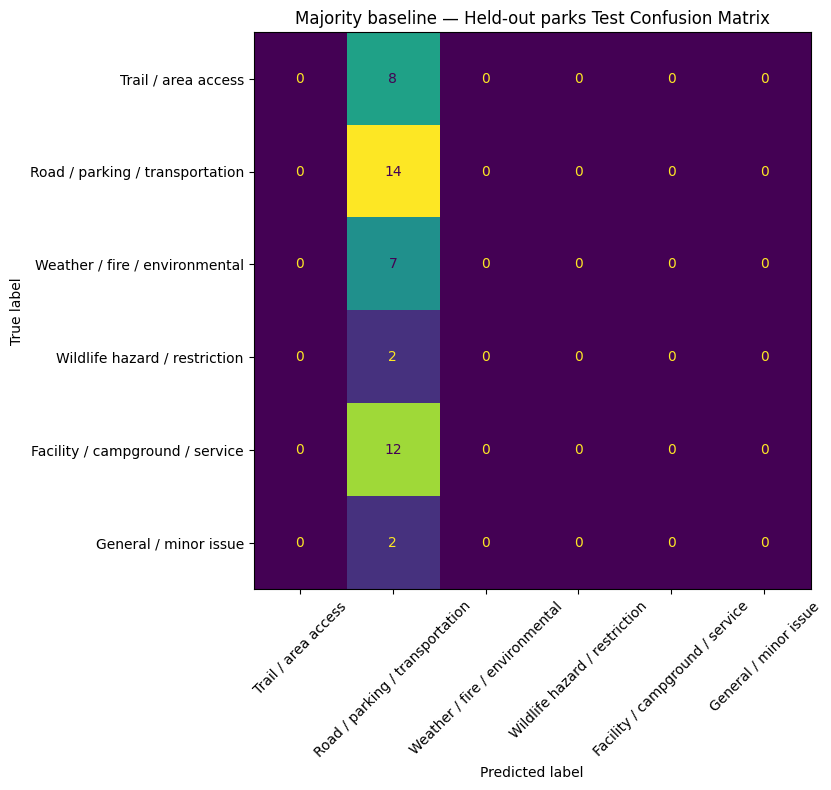

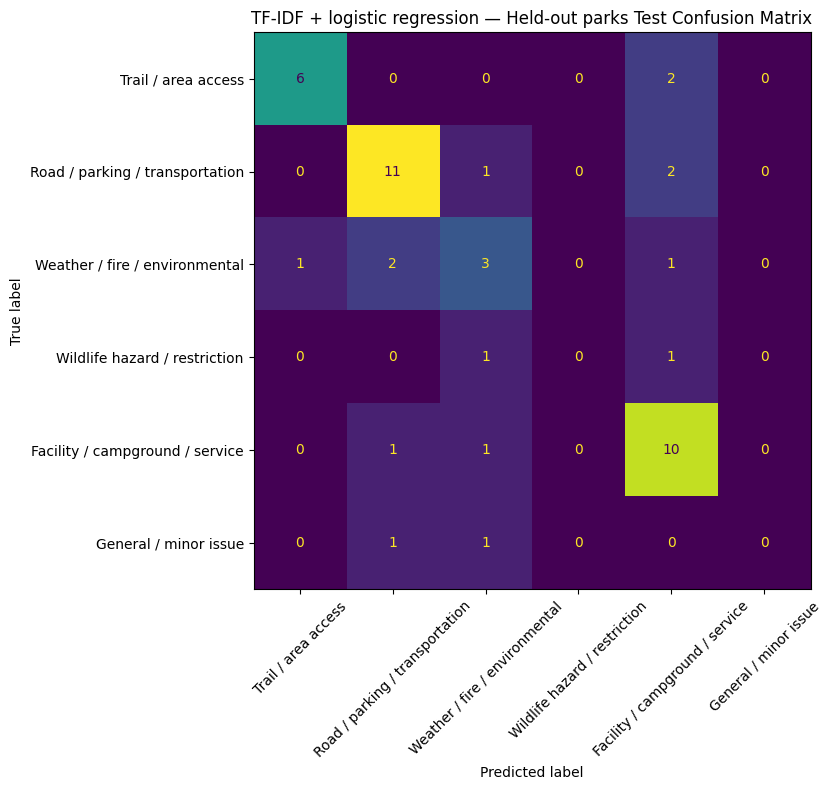

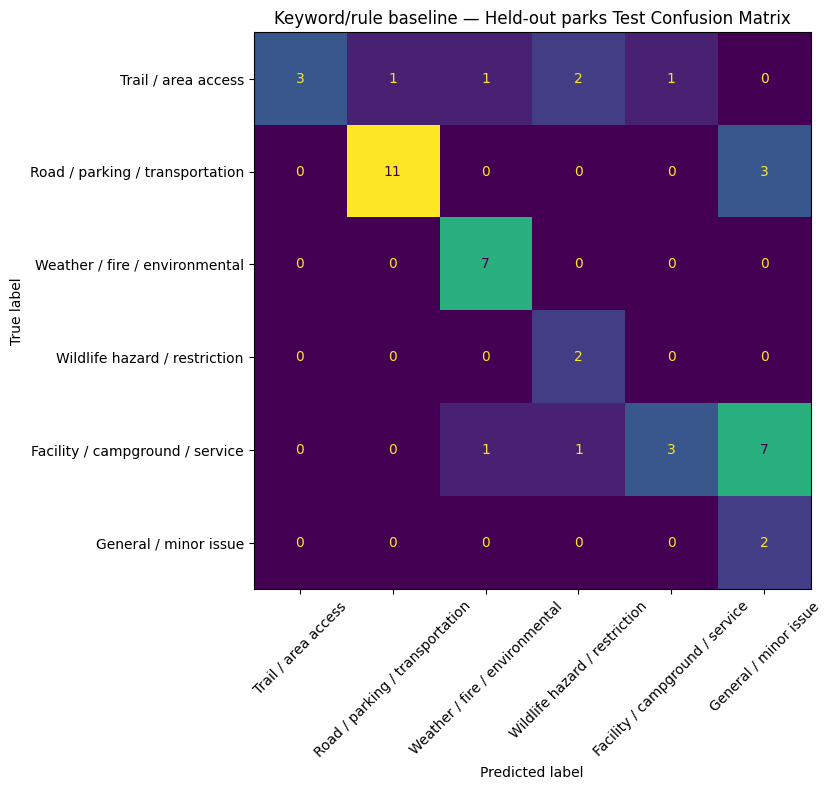

In [ ]:

heldout_frames = run_baselines_for_setting(
    frame=modeling_df,
    split_column="heldout_park_split",
    evaluation_setting="Held-out parks",
)



# Secondary evaluation: mixed parks



mixed_park_split — train: 210 records, 164 parks
mixed_park_split — validation: 45 records, 42 parks
mixed_park_split — test: 45 records, 42 parks


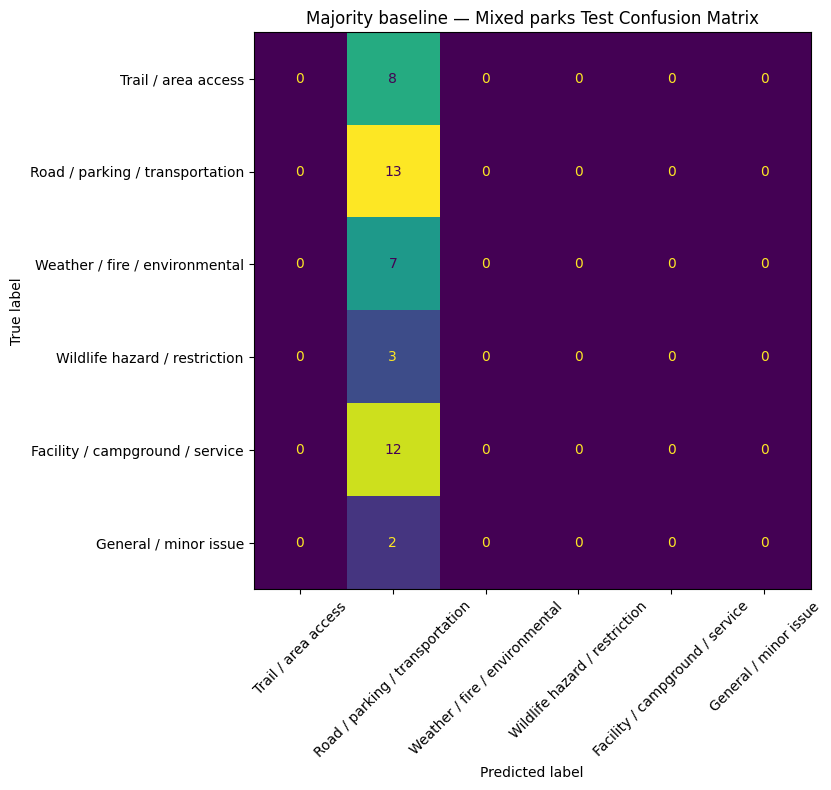

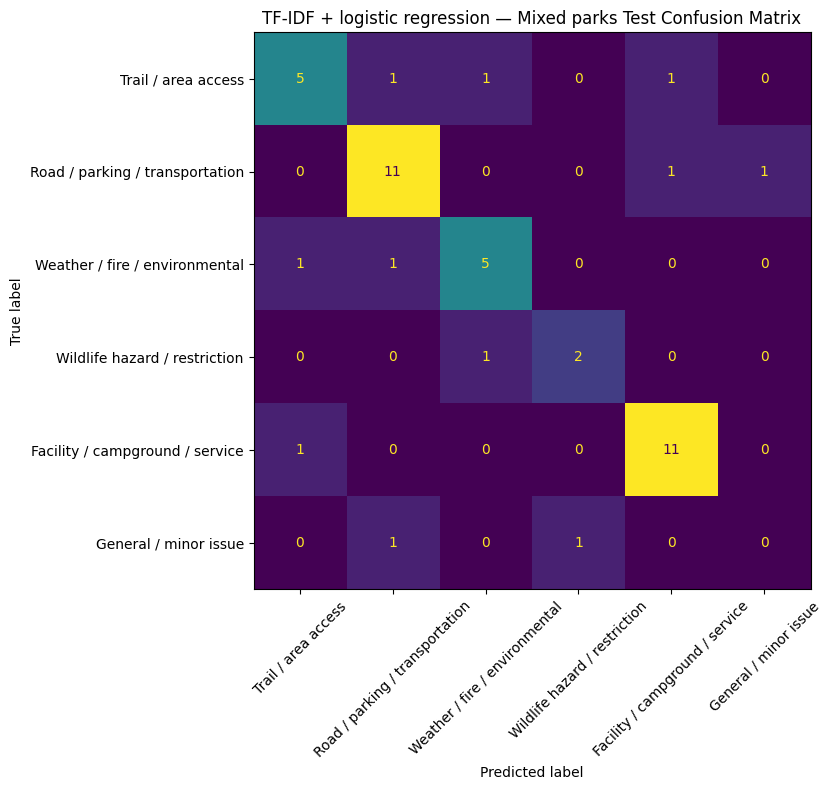

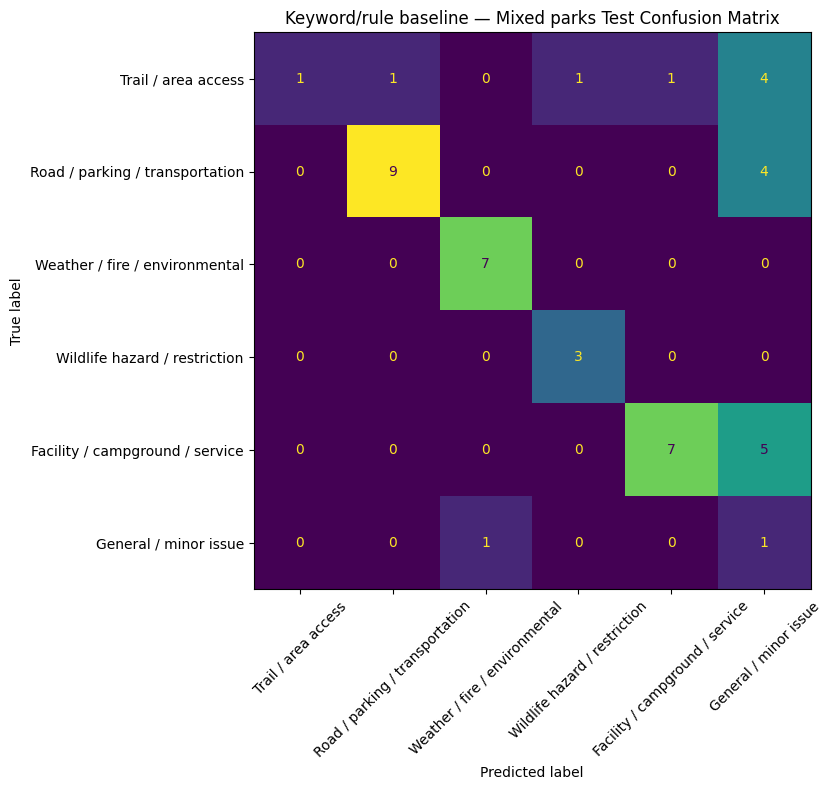

In [ ]:

mixed_frames = run_baselines_for_setting(
    frame=modeling_df,
    split_column="mixed_park_split",
    evaluation_setting="Mixed parks",
)


## 8. Consolidated validation and test results

In [ ]:

metrics_df = pd.DataFrame(all_metric_rows)

metrics_df = metrics_df[
    [
        "evaluation_setting",
        "partition",
        "model",
        "n",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values(
    [
        "partition",
        "evaluation_setting",
        "macro_f1",
    ],
    ascending=[True, True, False],
)

class_metrics_df = pd.concat(
    all_class_metric_tables,
    ignore_index=True,
)

predictions_df = pd.concat(
    all_prediction_tables,
    ignore_index=True,
)

print("Validation results:")
display(
    metrics_df.loc[
        metrics_df["partition"].eq("validation")
    ].reset_index(drop=True)
)

print("\nTest results:")
display(
    metrics_df.loc[
        metrics_df["partition"].eq("test")
    ].reset_index(drop=True)
)


Validation results:


,evaluation_setting,partition,model,n,accuracy,macro_f1,weighted_f1
0,Held-out parks,validation,Keyword/rule baseline,44,0.636364,0.659264,0.663038
1,Held-out parks,validation,TF-IDF + logistic regression,44,0.727273,0.639080,0.704088
2,Held-out parks,validation,Majority baseline,44,0.227273,0.061728,0.084175
3,Mixed parks,validation,Keyword/rule baseline,45,0.577778,0.585391,0.621809
4,Mixed parks,validation,TF-IDF + logistic regression,45,0.733333,0.544905,0.703762
5,Mixed parks,validation,Majority baseline,45,0.288889,0.074713,0.129502



Test results:


,evaluation_setting,partition,model,n,accuracy,macro_f1,weighted_f1
0,Held-out parks,test,Keyword/rule baseline,45,0.622222,0.583125,0.634424
1,Held-out parks,test,TF-IDF + logistic regression,45,0.666667,0.450246,0.635380
2,Held-out parks,test,Majority baseline,45,0.311111,0.079096,0.147646
3,Mixed parks,test,TF-IDF + logistic regression,45,0.755556,0.623739,0.744132
4,Mixed parks,test,Keyword/rule baseline,45,0.622222,0.603385,0.660143
5,Mixed parks,test,Majority baseline,45,0.288889,0.074713,0.129502



## 9. Primary test-results table



In [ ]:

test_metrics = metrics_df.loc[
    metrics_df["partition"].eq("test")
].copy()

primary_results = (
    test_metrics.pivot(
        index="model",
        columns="evaluation_setting",
        values="macro_f1",
    )
    .rename_axis(None, axis=1)
)

primary_results["Generalization gap"] = (
    primary_results["Mixed parks"]
    - primary_results["Held-out parks"]
)

primary_results = primary_results[
    [
        "Held-out parks",
        "Mixed parks",
        "Generalization gap",
    ]
].sort_values(
    "Held-out parks",
    ascending=False,
)

display(primary_results.round(3))


,Held-out parks,Mixed parks,Generalization gap
model,,,
Keyword/rule baseline,0.583,0.603,0.020
TF-IDF + logistic regression,0.450,0.624,0.173
Majority baseline,0.079,0.075,-0.004


## 10. Test-set performance chart

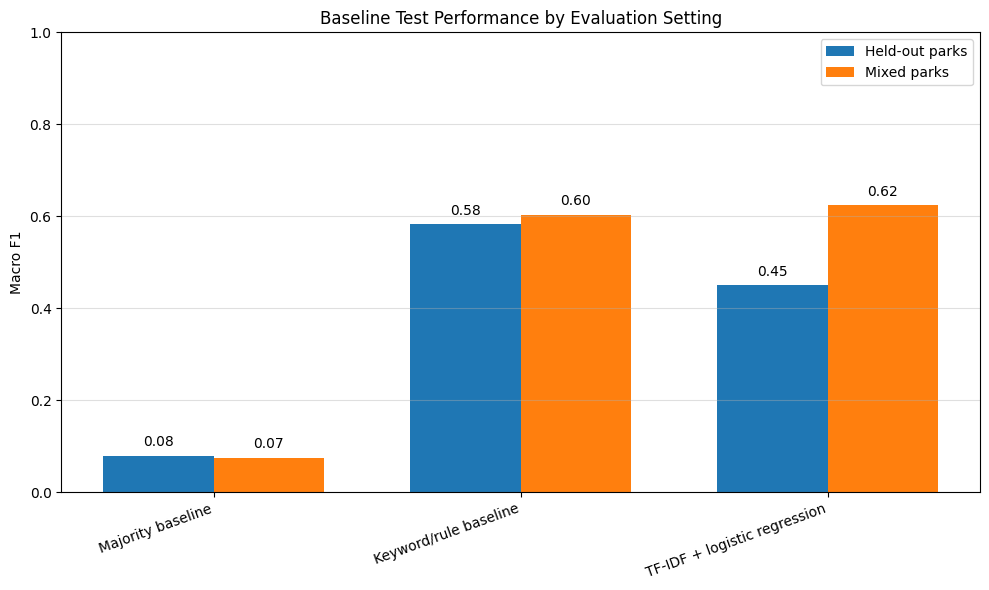

In [ ]:

plot_df = test_metrics.copy()

model_order = [
    "Majority baseline",
    "Keyword/rule baseline",
    "TF-IDF + logistic regression",
]

x = np.arange(len(model_order))
width = 0.36

heldout_values = [
    plot_df.loc[
        plot_df["model"].eq(model)
        & plot_df["evaluation_setting"].eq("Held-out parks"),
        "macro_f1",
    ].iloc[0]
    for model in model_order
]

mixed_values = [
    plot_df.loc[
        plot_df["model"].eq(model)
        & plot_df["evaluation_setting"].eq("Mixed parks"),
        "macro_f1",
    ].iloc[0]
    for model in model_order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width / 2, heldout_values, width, label="Held-out parks")
ax.bar(x + width / 2, mixed_values, width, label="Mixed parks")

ax.set_ylabel("Macro F1")
ax.set_title("Baseline Test Performance by Evaluation Setting")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", linewidth=0.8, alpha=0.4)

for index, value in enumerate(heldout_values):
    ax.text(
        index - width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

for index, value in enumerate(mixed_values):
    ax.text(
        index + width / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()


## 11. Per-class test metrics

In [ ]:

for evaluation_setting in ["Held-out parks", "Mixed parks"]:
    print(f"\n{evaluation_setting.upper()}")

    display(
        class_metrics_df.loc[
            class_metrics_df["partition"].eq("test")
            & class_metrics_df["evaluation_setting"].eq(evaluation_setting)
        ][
            [
                "model",
                "display_label",
                "precision",
                "recall",
                "f1",
                "support",
            ]
        ]
        .sort_values(["model", "support"], ascending=[True, False])
        .reset_index(drop=True)
    )



HELD-OUT PARKS


,model,display_label,precision,recall,f1,support
0,Keyword/rule baseline,Road / parking / transportation,0.916667,0.785714,0.846154,14
1,Keyword/rule baseline,Facility / campground / service,0.750000,0.250000,0.375000,12
2,Keyword/rule baseline,Trail / area access,1.000000,0.375000,0.545455,8
3,Keyword/rule baseline,Weather / fire / environmental,0.777778,1.000000,0.875000,7
4,Keyword/rule baseline,Wildlife hazard / restriction,0.400000,1.000000,0.571429,2
5,Keyword/rule baseline,General / minor issue,0.166667,1.000000,0.285714,2
6,Majority baseline,Road / parking / transportation,0.311111,1.000000,0.474576,14
7,Majority baseline,Facility / campground / service,0.000000,0.000000,0.000000,12
8,Majority baseline,Trail / area access,0.000000,0.000000,0.000000,8
9,Majority baseline,Weather / fire / environmental,0.000000,0.000000,0.000000,7



MIXED PARKS


,model,display_label,precision,recall,f1,support
0,Keyword/rule baseline,Road / parking / transportation,0.900000,0.692308,0.782609,13
1,Keyword/rule baseline,Facility / campground / service,0.875000,0.583333,0.700000,12
2,Keyword/rule baseline,Trail / area access,1.000000,0.125000,0.222222,8
3,Keyword/rule baseline,Weather / fire / environmental,0.875000,1.000000,0.933333,7
4,Keyword/rule baseline,Wildlife hazard / restriction,0.750000,1.000000,0.857143,3
5,Keyword/rule baseline,General / minor issue,0.071429,0.500000,0.125000,2
6,Majority baseline,Road / parking / transportation,0.288889,1.000000,0.448276,13
7,Majority baseline,Facility / campground / service,0.000000,0.000000,0.000000,12
8,Majority baseline,Trail / area access,0.000000,0.000000,0.000000,8
9,Majority baseline,Weather / fire / environmental,0.000000,0.000000,0.000000,7



## 12. Error analysis for TF-IDF logistic regression



In [ ]:

tfidf_errors = predictions_df.loc[
    predictions_df["partition"].eq("test")
    & predictions_df["model"].eq("TF-IDF + logistic regression")
    & ~predictions_df["correct"]
].copy()

print("Held-out-park TF-IDF errors:")
display(
    tfidf_errors.loc[
        tfidf_errors["evaluation_setting"].eq("Held-out parks")
    ][
        [
            "parkCode",
            "title",
            "primary_label",
            "predicted_label",
        ]
    ].reset_index(drop=True)
)

print("\nMixed-park TF-IDF errors:")
display(
    tfidf_errors.loc[
        tfidf_errors["evaluation_setting"].eq("Mixed parks")
    ][
        [
            "parkCode",
            "title",
            "primary_label",
            "predicted_label",
        ]
    ].reset_index(drop=True)
)


Held-out-park TF-IDF errors:


,parkCode,title,primary_label,predicted_label
0,neph,Avoid Ticks on Site!,wildlife_hazard_or_restriction,weather_fire_environmental_hazard
1,beol,Do Not Handle Wildlife,wildlife_hazard_or_restriction,facility_water_campground_service
2,cave,Footwear in the Cavern,facility_water_campground_service,weather_fire_environmental_hazard
3,edis,Glenmont Heat Advisory,weather_fire_environmental_hazard,facility_water_campground_service
4,edis,Heat Warning,weather_fire_environmental_hazard,road_parking_transportation
5,wrst,Lakina River Update,weather_fire_environmental_hazard,road_parking_transportation
6,fowa,"Lighthouse Area Closed until June 30, 2026",trail_or_area_access,facility_water_campground_service
7,till,Ongoing Construction at the Emmett Till Interp...,facility_water_campground_service,road_parking_transportation
8,muwo,Parking Reservations Always Required,road_parking_transportation,facility_water_campground_service
9,beol,Plaza Access to Reconstructed Fort,trail_or_area_access,facility_water_campground_service



Mixed-park TF-IDF errors:


,parkCode,title,primary_label,predicted_label
0,noca,Be Aware of Break-ins along State Route 20,road_parking_transportation,construction_maintenance_general
1,pais,Canine distemper is believed to be present in ...,wildlife_hazard_or_restriction,weather_fire_environmental_hazard
2,chis,Closure of Santa Rosa Island Due to Wildfire,weather_fire_environmental_hazard,trail_or_area_access
3,choh,Closures: Detours; Towpath; Points of Interest,trail_or_area_access,weather_fire_environmental_hazard
4,natr,Current Park Closures,construction_maintenance_general,road_parking_transportation
5,fosu,Fort Moultrie Fishing Dock Closure,facility_water_campground_service,trail_or_area_access
6,wrst,Lakina River Update,weather_fire_environmental_hazard,road_parking_transportation
7,anjo,Notice to travelers to National Cemetery,road_parking_transportation,facility_water_campground_service
8,fiis,Possession or use of marijuana inside Fire Isl...,construction_maintenance_general,wildlife_hazard_or_restriction
9,tusk,South Unit temporarily closed south of Grand T...,trail_or_area_access,road_parking_transportation



## 13. Inspect the most influential TF-IDF features


In [ ]:

heldout_tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            stop_words="english",
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

heldout_tfidf_model.fit(
    heldout_frames["train"]["text_title_description"],
    heldout_frames["train"]["primary_label"],
)

feature_names = np.array(
    heldout_tfidf_model.named_steps["tfidf"].get_feature_names_out()
)

classifier = heldout_tfidf_model.named_steps["classifier"]

top_feature_rows = []

for class_index, class_label in enumerate(classifier.classes_):
    coefficients = classifier.coef_[class_index]
    top_indices = np.argsort(coefficients)[-12:][::-1]

    for rank, feature_index in enumerate(top_indices, start=1):
        top_feature_rows.append({
            "primary_label": class_label,
            "display_label": DISPLAY_LABELS[class_label],
            "rank": rank,
            "feature": feature_names[feature_index],
            "coefficient": coefficients[feature_index],
        })

top_features_df = pd.DataFrame(top_feature_rows)

display(top_features_df)


,primary_label,display_label,rank,feature,coefficient
0,construction_maintenance_general,General / minor issue,1,car,0.851377
1,construction_maintenance_general,General / minor issue,2,current,0.790478
2,construction_maintenance_general,General / minor issue,3,valuables,0.678265
3,construction_maintenance_general,General / minor issue,4,ferry,0.636532
4,construction_maintenance_general,General / minor issue,5,warning,0.623404
...,...,...,...,...,...
67,wildlife_hazard_or_restriction,Wildlife hazard / restriction,8,goodell creek,0.460684
68,wildlife_hazard_or_restriction,Wildlife hazard / restriction,9,goodell,0.460684
69,wildlife_hazard_or_restriction,Wildlife hazard / restriction,10,island,0.431545
70,wildlife_hazard_or_restriction,Wildlife hazard / restriction,11,bears,0.422477


## 14. Export results and predictions

In [ ]:

preferred_output_dirs = [
    Path("/content/nps_baseline_outputs"),
    Path("/mnt/data/nps_baseline_outputs"),
    Path("nps_baseline_outputs"),
]

output_dir = None

for candidate_dir in preferred_output_dirs:
    try:
        candidate_dir.mkdir(parents=True, exist_ok=True)
        output_dir = candidate_dir
        break
    except (PermissionError, OSError):
        continue

if output_dir is None:
    raise PermissionError("Could not create an output directory.")

metrics_df.to_csv(
    output_dir / "baseline_overall_metrics.csv",
    index=False,
)

class_metrics_df.to_csv(
    output_dir / "baseline_per_class_metrics.csv",
    index=False,
)

predictions_df.to_csv(
    output_dir / "baseline_predictions.csv",
    index=False,
)

tfidf_errors.to_csv(
    output_dir / "tfidf_test_errors.csv",
    index=False,
)

top_features_df.to_csv(
    output_dir / "heldout_tfidf_top_features.csv",
    index=False,
)

primary_results.to_csv(
    output_dir / "baseline_generalization_gap.csv"
)

with pd.ExcelWriter(
    output_dir / "baseline_results_summary.xlsx",
    engine="openpyxl",
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="Overall_Metrics",
        index=False,
    )
    class_metrics_df.to_excel(
        writer,
        sheet_name="Per_Class_Metrics",
        index=False,
    )
    primary_results.to_excel(
        writer,
        sheet_name="Generalization_Gap",
    )
    tfidf_errors.to_excel(
        writer,
        sheet_name="TFIDF_Errors",
        index=False,
    )
    top_features_df.to_excel(
        writer,
        sheet_name="Top_Features",
        index=False,
    )

print("Saved outputs to:", output_dir.resolve())

for file_path in sorted(output_dir.iterdir()):
    print("-", file_path.name)


Saved outputs to: /content/nps_baseline_outputs
- baseline_generalization_gap.csv
- baseline_overall_metrics.csv
- baseline_per_class_metrics.csv
- baseline_predictions.csv
- baseline_results_summary.xlsx
- heldout_tfidf_top_features.csv
- tfidf_test_errors.csv
